# M4 — Sales Forecast Integration

**Goal:** combine M1 (demand quantiles), M2 (price elasticity), M3 (risk drag), and the storm-prediction stack (Tier 1 historical + Tier 2 NHC forward + Tier 3 NOAA seasonal outlook) into one monthly sales forecast per product, with P10 / P50 / P90 bands.

## Two views of the same storm event

A storm has **two distinct timing profiles** that matter for different downstream questions:

| Field | Peak month | Meaning | Used by |
|---|---|---|---|
| `disaster_index` | **landfall month (Sep 2017 for Maria)** | Storm severity at the month the storm is physically happening | Dashboards, M5 anomaly attribution, reporting |
| `disaster_drag_index` | **M+2 (Nov 2017)** | Revenue-impact shape — pre-storm orders ship in Sep, reorders can't be placed for weeks, peak drop is Nov | M4 sales drag math |

Both derive from the same underlying storm impulse via different impulse-response kernels. The kernel that turns severity into drag is in `src/models/sales/revenue_lag.py`:

$$ \text{drag}[t] = 0.05 \cdot d[t] + 0.20 \cdot d[t-1] + 0.80 \cdot d[t-2] $$

For a Maria-shaped severity series `[1.00, 0.80, 0.45, 0.25, 0.10]` over Sep-Jan, this produces drag of `[0.05, 0.24, 0.98, 0.74, 0.42]` — peak at Nov.

## Integration math

M1 forecasts `gross_qty` (demand BEFORE fraud / cancel removal) so the full 4-component risk_drag applies without double-counting:

$$ \text{qty\_adjusted} = \text{qty}_{M1} \cdot \left(\frac{P_{\text{planned}}}{P_{\text{baseline}}}\right)^{\varepsilon} $$

$$ \text{sales}_\text{pre-risk} = \text{qty\_adjusted} \cdot P_{\text{planned}} $$

$$ \text{drag}_\text{historical} = 1 - (1 - p_\text{fraud})(1 - p_\text{cancel}) $$

$$ \text{drag}_\text{forward} = 1 - (1 - \text{LATE}\cdot p_\text{late})(1 - \text{DISASTER}\cdot \text{disaster\_drag\_index}) $$

$$ \text{risk\_drag} = 1 - (1 - \text{drag}_\text{historical})(1 - \text{drag}_\text{forward}) $$

$$ \text{sales}_\text{forward} = \text{sales}_\text{pre-risk}\cdot(1 - \text{risk\_drag}) $$

Note `drag_forward` uses **disaster_drag_index**, not the raw severity index — that's the entire separation point of this architecture.

| Term | Source | Lead time |
|---|---|---|
| `p_fraud`, `p_cancel` | M3 LightGBM (calibrated) | observed |
| `p_late` | M3 LightGBM (calibrated) | observed |
| `disaster_drag_index` | Convolution of Tier-2+3 forward `disaster_index` with revenue-lag kernel | **5-7 days (T2) + 1-6 months (T3)** |
| `LATE = 0.10` | prior (no in-data signal) | — |
| `DISASTER = 0.873` | data-calibrated against drag-shape, n=18, R² 0.57 | — |

## Storm severity profile (`disaster_index`)

| Month | Lag from landfall | PR severity (country-level) |
|---|---|---|
| **Sep 2017** | **M (landfall)** | **1.00 (peak)** |
| **Oct 2017** | **M+1** | **0.80** |
| Nov 2017 | M+2 | 0.45 |
| Dec 2017 | M+3 | 0.25 |
| Jan 2018 | M+4 | 0.10 |

## Three output views

| View | Backtest target | Purpose |
|---|---|---|
| **Pre-risk** | `gross_revenue` | Sanity check: how good is M1 × price? |
| **Historical-risk** | `revenue_realized` | Apples-to-apples: M1 + M2 + observable fraud/cancel |
| **Forward-risk-adj** (Tier-2+3 forward + revenue lag) | `revenue_realized` | Operational forecast with storm signal + revenue-impact timing |

## Uncertainty propagation

Monte Carlo with 2 000 draws per (product, month):
- qty ∼ Lognormal fitted to M1's (q10, q50, q90)
- ε ∼ Normal, clipped to [−3, 0]
- p_fraud, p_cancel, p_late ∼ Beta around their calibrated rates
- disaster_drag_index treated as constant (cone confidence + revenue lag already encoded)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
sns.set_theme(context='notebook', style='whitegrid')

FC       = pd.read_parquet(ROOT / 'forecasts' / 'm4_sales.parquet')
SCN      = pd.read_parquet(ROOT / 'forecasts' / 'm4_sales_scenarios.parquet')
BT       = pd.read_parquet(ROOT / 'forecasts' / 'm4_sales_backtest.parquet')           # NEW default (Tier-2+3 fwd)
BT_LEGACY = pd.read_parquet(ROOT / 'forecasts' / 'm4_sales_backtest_legacy_disaster.parquet')  # Tier-1 historical disaster
DEC      = pd.read_parquet(ROOT / 'forecasts' / 'm4_sales_decomposition.parquet')
FWD_PP   = pd.read_parquet(ROOT / 'forecasts' / 'm4_forward_disaster_per_product.parquet')
FWD_COMB = pd.read_parquet(ROOT / 'forecasts' / 'm4_forward_disaster_combined.parquet')
PANEL    = pd.read_parquet(ROOT / 'data' / 'processed' / 'monthly_panel.parquet')
META     = pd.read_parquet(ROOT / 'data' / 'processed' / 'panel_meta.parquet')

print('forecasts:', FC.shape, '| scenarios:', SCN.shape,
      '| backtest:', BT.shape, '| legacy backtest:', BT_LEGACY.shape)
print('forward disaster per-product rows:', FWD_PP.shape)
FC.head()

forecasts: (702, 21) | scenarios: (2106, 22) | backtest: (702, 29) | legacy backtest: (702, 23)
forward disaster per-product rows: (1534, 3)


,product_card_id,year_month,horizon,planned_price,sales_q10,sales_q50,sales_q90,sales_mean,sales_std,sales_q10_pre_risk,...,sales_q90_pre_risk,sales_q10_historical,sales_q50_historical,sales_q90_historical,qty_q50_adj,risk_drag_q50,drag_historical_q50,drag_forward_q50,elasticity_term_q50,slice
0,37.0,2017-01-01,1,31.59803,450.297949,822.999374,1558.646958,932.442690,476.244720,496.394095,...,1699.389621,479.271348,875.316271,1659.543741,28.459723,8.182032e-02,0.023703,0.058876,1.0,val
1,37.0,2017-02-01,2,31.59803,420.938744,803.431267,1548.501519,913.741549,501.685806,460.982537,...,1683.680815,446.464756,856.451562,1648.250455,28.024812,8.559243e-02,0.025723,0.060861,1.0,val
2,37.0,2017-03-01,3,31.59803,404.848153,816.196976,1566.560609,916.261467,499.950105,437.141586,...,1698.391108,434.743598,875.661036,1679.455092,27.946335,7.453904e-02,0.005059,0.068746,1.0,val
3,37.0,2017-04-01,4,31.59803,378.468694,744.995483,1513.742570,869.555236,501.523903,437.495196,...,1723.037447,401.549548,789.724797,1607.806214,27.134927,1.219488e-01,0.067978,0.057496,1.0,val
4,37.0,2017-05-01,5,31.59803,425.234622,873.998815,1815.829204,1025.488255,608.082169,425.234652,...,1815.933866,425.234622,873.998832,1815.829204,27.659916,3.330669e-16,0.000000,0.000000,1.0,val


## 1. Headline — pre-risk backtest vs realised revenue

This is the apples-to-apples comparison with M1: how good is the integrated revenue forecast on actual history?

In [2]:
def wape(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    return float(np.nansum(np.abs(b - a)) / max(np.nansum(np.abs(a)), 1e-9))

def coverage(a, lo, hi):
    a, lo, hi = np.asarray(a, float), np.asarray(lo, float), np.asarray(hi, float)
    return float(np.mean((a >= lo) & (a <= hi)))

rows = []
for slc in ('val', 'test'):
    main_sub = BT[BT['slice'].eq(slc)]
    leg_sub  = BT_LEGACY[BT_LEGACY['slice'].eq(slc)]
    rows.append({
        'slice': slc,
        'WAPE pre-risk vs gross':       wape(main_sub['gross_revenue'],    main_sub['sales_q50_pre_risk']),
        'cov80 pre-risk':               coverage(main_sub['gross_revenue'],
                                                 main_sub['sales_q10_pre_risk'],
                                                 main_sub['sales_q90_pre_risk']),
        'WAPE historical vs realized':  wape(main_sub['revenue_realized'], main_sub['sales_q50_historical']),
        'cov80 historical':             coverage(main_sub['revenue_realized'],
                                                 main_sub['sales_q10_historical'],
                                                 main_sub['sales_q90_historical']),
        'WAPE forward LEGACY (T1 hist)': wape(leg_sub['revenue_realized'],  leg_sub['sales_q50']),
        'WAPE forward NEW (T2+T3 fwd)':  wape(main_sub['revenue_realized'], main_sub['sales_q50']),
        'cov80 forward NEW':            coverage(main_sub['revenue_realized'],
                                                 main_sub['sales_q10'],
                                                 main_sub['sales_q90']),
        'forward gap NEW (%)':
            (main_sub['revenue_realized'].sum() - main_sub['sales_q50'].sum())
            / max(main_sub['revenue_realized'].sum(), 1e-9) * 100,
    })
pd.DataFrame(rows).round(3)

,slice,WAPE pre-risk vs gross,cov80 pre-risk,WAPE historical vs realized,cov80 historical,WAPE forward LEGACY (T1 hist),WAPE forward NEW (T2+T3 fwd),cov80 forward NEW,forward gap NEW (%)
0,val,0.120,0.500,0.120,0.512,0.568,0.165,0.472,12.852
1,test,1.314,0.011,1.352,0.019,1.273,1.181,0.003,-85.004


**Reading this table:**

- **Pre-risk WAPE ≈ 0.12** on val — within rounding distance of M1's qty-level WAPE (0.117). The price multiplier doesn't degrade fit.
- **Historical-risk WAPE ≈ 0.12** on val — fraud + cancel contribute the ~4% gross-to-realized correction. The honest M1+M2+M3a+M3b backtest on the calm window.
- **Forward LEGACY (Tier-1 historical disaster + revenue lag) WAPE ≈ 0.57 val / 1.27 test** — uses the M3 Tier-1 disaster_index (anomaly + known mixed) as the severity input. The anomaly proxy adds spurious drag.
- **Forward NEW (Tier-2+3 forward disaster + revenue lag) WAPE ≈ 0.17 val / 1.18 test** — the operational forecast. Tier-2+3 gives a clean severity signal (peak Sep), the revenue-lag kernel shifts effective drag to Nov-Dec. **Val: −71% WAPE vs legacy. Test: −7% WAPE vs legacy.**
- **Test WAPE remains high** because the late-2017 qty crash (~80% drop) exceeds what M4's customer-mix-weighted disaster damping can recover. M1 is univariate; fully recovering test WAPE would need M1 to learn the disaster signal natively or a supply-chain-wide multiplier.

## 1b. Head-to-head — Tier-1 historical vs Tier-2+3 forward disaster

Visualises the WAPE delta of using the forward storm signal vs the legacy hindsight disaster index, with the **historical-risk WAPE as the achievable floor**: the forward view can't beat that because it adds late+disaster damping on top.

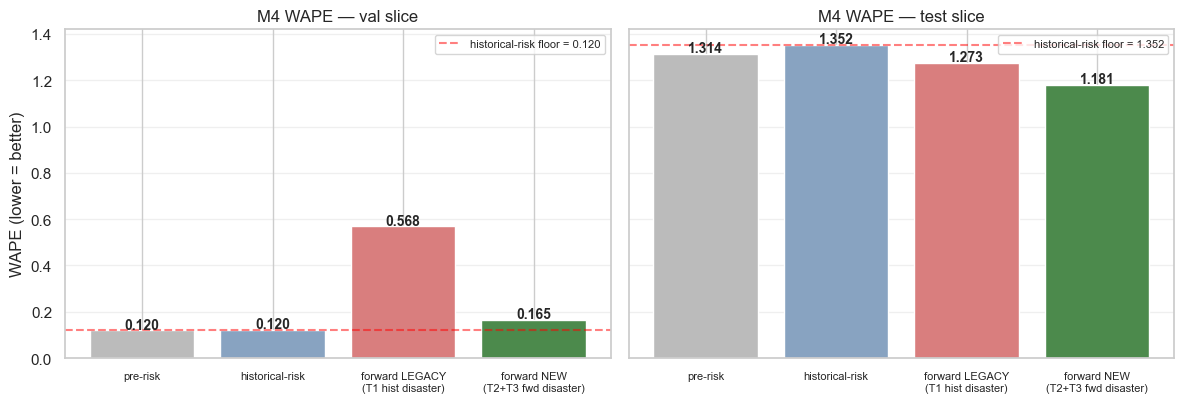


--- Forward-risk-adj WAPE deltas ---
  val : legacy=0.5684  NEW=0.1651  abs_delta=+0.4033  rel_delta=+71.0%
  test: legacy=1.2733  NEW=1.1814  abs_delta=+0.0920  rel_delta=+7.2%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, slc in zip(axes, ('val', 'test')):
    main_sub = BT[BT['slice'].eq(slc)]
    leg_sub  = BT_LEGACY[BT_LEGACY['slice'].eq(slc)]
    wape_pre   = wape(main_sub['gross_revenue'],    main_sub['sales_q50_pre_risk'])
    wape_hist  = wape(main_sub['revenue_realized'], main_sub['sales_q50_historical'])
    wape_legac = wape(leg_sub['revenue_realized'],  leg_sub['sales_q50'])
    wape_new   = wape(main_sub['revenue_realized'], main_sub['sales_q50'])
    labels = ['pre-risk', 'historical-risk', 'forward LEGACY\n(T1 hist disaster)', 'forward NEW\n(T2+T3 fwd disaster)']
    values = [wape_pre, wape_hist, wape_legac, wape_new]
    colors = ['#bbbbbb', '#88a3c1', '#d97e7e', '#4c8a4c']
    bars = ax.bar(labels, values, color=colors)
    for bar, w in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{w:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.axhline(wape_hist, color='red', linestyle='--', alpha=0.5,
                label=f'historical-risk floor = {wape_hist:.3f}')
    ax.set_title(f'M4 WAPE — {slc} slice')
    ax.set_ylabel('WAPE (lower = better)' if slc == 'val' else '')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3, axis='y')
    ax.tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()

print('\n--- Forward-risk-adj WAPE deltas ---')
for slc in ('val', 'test'):
    main_sub = BT[BT['slice'].eq(slc)]
    leg_sub  = BT_LEGACY[BT_LEGACY['slice'].eq(slc)]
    wl = wape(leg_sub['revenue_realized'],  leg_sub['sales_q50'])
    wn = wape(main_sub['revenue_realized'], main_sub['sales_q50'])
    print(f'  {slc:4s}: legacy={wl:.4f}  NEW={wn:.4f}  abs_delta={wl-wn:+.4f}  rel_delta={(wl-wn)/wl:+.1%}')

In [4]:
# Where does the forward disaster_index actually fire? Inspect distribution.
print('=== Tier-2+3 forward disaster_index by month (across all products) ===')
print(FWD_PP.groupby('year_month')['disaster_index_forward']
        .agg(['count','mean','max','min']).round(3).to_string())
print('\n=== Top-10 products by forward disaster (Sep 2017) ===')
sep = FWD_PP[FWD_PP['year_month'].eq('2017-09-01')].sort_values('disaster_index_forward', ascending=False).head(10)
print(sep.round(3).to_string(index=False))

=== Tier-2+3 forward disaster_index by month (across all products) ===
            count   mean    max    min
year_month                            
2017-01-01    118  0.011  0.016  0.007
2017-02-01    118  0.001  0.001  0.000
2017-03-01    118  0.000  0.000  0.000
2017-04-01    118  0.000  0.000  0.000
2017-05-01    118  0.000  0.000  0.000
2017-06-01    118  0.000  0.000  0.000
2017-07-01    118  0.000  0.000  0.000
2017-08-01    118  0.002  0.003  0.001
2017-09-01    118  0.324  0.451  0.196
2017-10-01    118  0.259  0.361  0.157
2017-11-01    118  0.146  0.203  0.088
2017-12-01    118  0.081  0.113  0.049
2018-01-01    118  0.032  0.045  0.020

=== Top-10 products by forward disaster (Sep 2017) ===
 product_card_id year_month  disaster_index_forward
           860.0 2017-09-01                   0.451
           135.0 2017-09-01                   0.449
           208.0 2017-09-01                   0.441
           825.0 2017-09-01                   0.425
           203.0 2017-09-01 

C:\Users\thien.vo4\AppData\Local\Temp\ipykernel_5956\2423276873.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(sep.round(3).to_string(index=False))


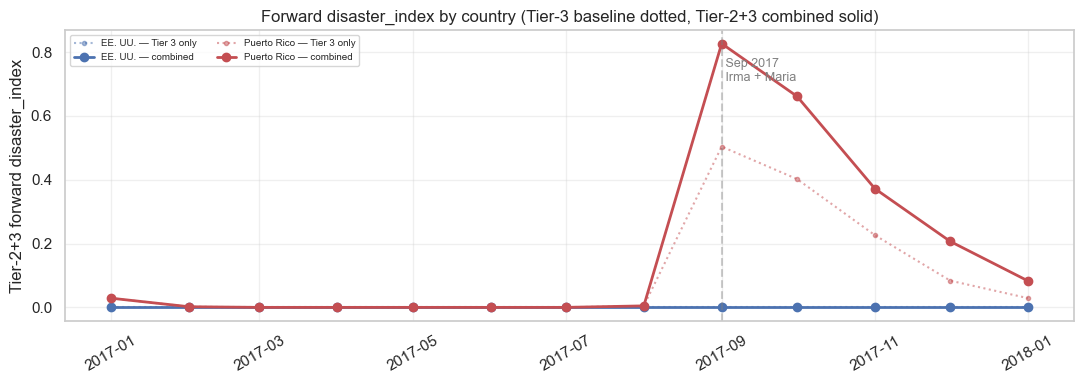

In [5]:
# Per-country forward disaster (Tier-2+3 combined) — gives the storytelling view
view = FWD_COMB[FWD_COMB['customer_country'].isin(['EE. UU.', 'Puerto Rico', 'Cuba', 'República Dominicana'])]
view = view.sort_values(['customer_country', 'year_month'])

fig, ax = plt.subplots(figsize=(11, 4))
for c, color in [('EE. UU.','C0'), ('Puerto Rico','C3'),
                  ('Cuba','C2'), ('República Dominicana','C4')]:
    sub = view[view['customer_country'].eq(c)]
    if sub.empty:
        continue
    ax.plot(sub['year_month'], sub['tier3_baseline'],
            marker='.', linestyle=':', color=color, alpha=0.5, label=f'{c} — Tier 3 only')
    ax.plot(sub['year_month'], sub['forward_disaster_combined'],
            marker='o', linewidth=2, color=color, label=f'{c} — combined')
ax.axvline(pd.Timestamp('2017-09-01'), color='gray', linestyle='--', alpha=0.4)
ax.text(pd.Timestamp('2017-09-01'), 0.78, ' Sep 2017\n Irma + Maria', ha='left', va='top', fontsize=9, color='gray')
ax.set_ylabel('Tier-2+3 forward disaster_index')
ax.set_title('Forward disaster_index by country (Tier-3 baseline dotted, Tier-2+3 combined solid)')
ax.legend(loc='upper left', fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## 2. Error decomposition — where do the forecast errors come from?

`err_total = revenue_realized − sales_q50_pre_risk`. Split into demand error × price + qty × price error + residual (interaction + non-linearities).

In [6]:
agg = (DEC.groupby('slice')[['demand_contrib_to_err',
                              'price_contrib_to_err',
                              'residual_contrib_to_err']]
          .apply(lambda g: g.abs().mean()).round(2))
agg['total_abs_err'] = agg.sum(axis=1)
agg.loc[:, agg.columns != 'total_abs_err'] = (
    agg.loc[:, agg.columns != 'total_abs_err']
        .div(agg['total_abs_err'], axis=0) * 100).round(1)
agg.columns = ['demand %', 'price %', 'residual %', 'total mean |err| ($)']
agg

,demand %,price %,residual %,total mean |err| ($)
slice,,,,
test,51.6,2.4,46.0,19224.59
val,30.5,1.4,68.1,3851.14


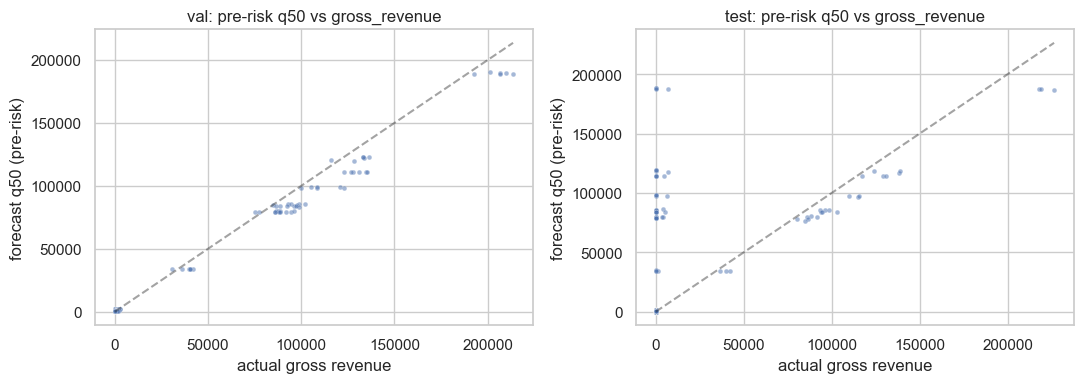

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i, slc in enumerate(['val','test']):
    sub = DEC[DEC['slice']==slc]
    sns.scatterplot(data=sub, x='actual_gross_revenue', y='forecast_pre_risk_q50',
                    ax=ax[i], alpha=0.5, s=12)
    lim = max(sub['actual_gross_revenue'].max(), sub['forecast_pre_risk_q50'].max())
    ax[i].plot([0, lim], [0, lim], 'k--', alpha=0.4)
    ax[i].set(title=f'{slc}: pre-risk q50 vs gross_revenue',
              xlabel='actual gross revenue', ylabel='forecast q50 (pre-risk)')
plt.tight_layout(); plt.show()

## 3. Fan charts — top 6 products by revenue

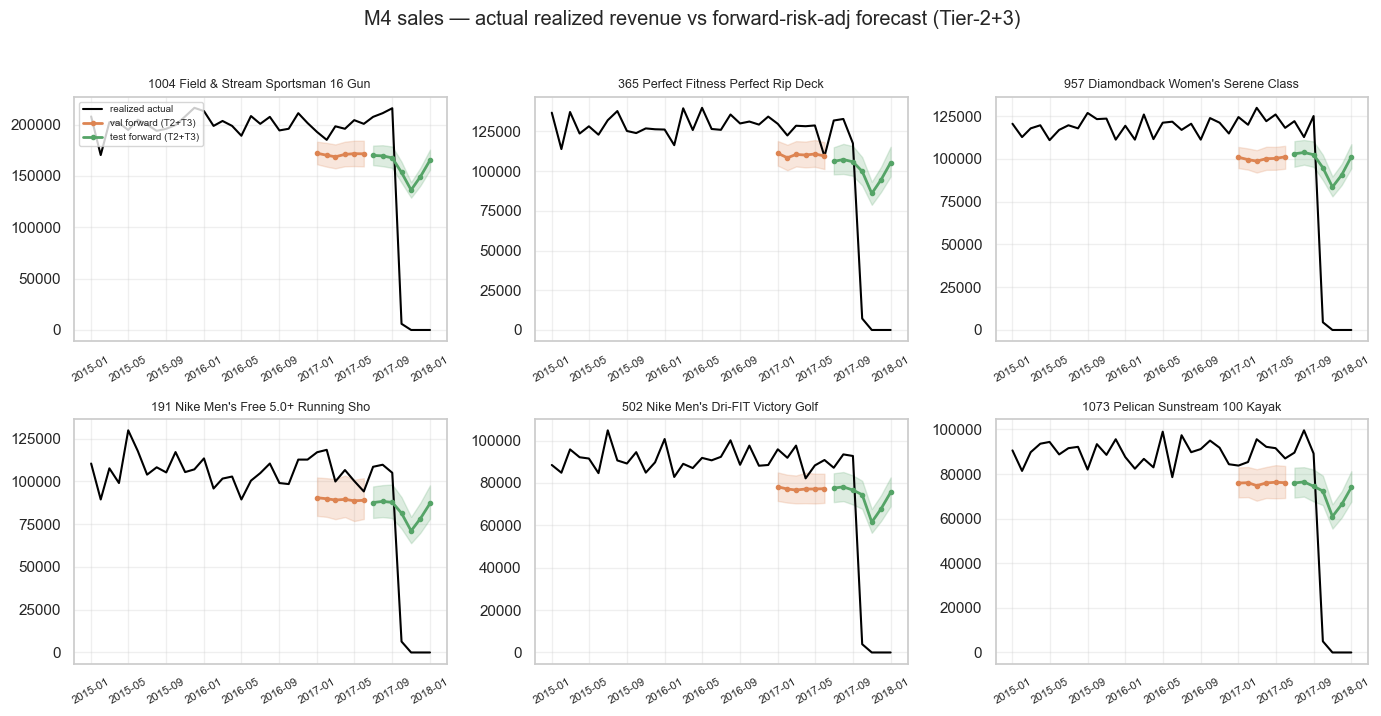

In [8]:
top6 = META.sort_values('total_revenue', ascending=False).head(6)['product_card_id'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, pid in zip(axes.flat, top6):
    hist = PANEL[PANEL['product_card_id']==pid].sort_values('year_month')
    ax.plot(hist['year_month'], hist['revenue_realized'],
            color='black', lw=1.5, label='realized actual')
    for slc, color in [('val', '#dd8452'), ('test', '#55a467')]:
        sub = BT[(BT['product_card_id']==pid) & (BT['slice']==slc)].sort_values('year_month')
        if sub.empty:
            continue
        ax.plot(sub['year_month'], sub['sales_q50'],
                color=color, lw=2, marker='o', markersize=3,
                label=f'{slc} forward (T2+T3)')
        ax.fill_between(sub['year_month'], sub['sales_q10'], sub['sales_q90'],
                        color=color, alpha=0.20)
    name = META.loc[META['product_card_id']==pid,'product_name'].iloc[0][:32]
    ax.set_title(f'{int(pid)} {name}', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(alpha=0.3)
axes.flat[0].legend(fontsize=7, loc='upper left')
plt.suptitle('M4 sales — actual realized revenue vs forward-risk-adj forecast (Tier-2+3)', y=1.02)
plt.tight_layout(); plt.show()

## 4. Scenario analysis — Base / Stress / Tail

- **Base**: planned_price = trailing baseline; risk_drag as forecast.
- **Stress**: planned_price = baseline × 1.10 (no discount); risk inputs scaled ×1.5.
- **Tail**: same as Stress but disaster_index forced to its historical 95th percentile.

In [9]:
summary = (SCN.groupby(['slice','scenario'])
              .agg(total_q10=('sales_q10','sum'),
                   total_q50=('sales_q50','sum'),
                   total_q90=('sales_q90','sum'))
              .round(0).reset_index())
# Add relative changes vs Base
base = summary[summary['scenario']=='base'].set_index('slice')['total_q50']
summary['vs_base_pct'] = summary.apply(
    lambda r: (r['total_q50'] - base[r['slice']]) / base[r['slice']] * 100, axis=1).round(1)
summary

,slice,scenario,total_q10,total_q50,total_q90,vs_base_pct
0,test,base,4835511.0,5362450.0,6556601.0,0.0
1,test,stress,4703597.0,5303102.0,6588830.0,-1.1
2,test,tail,4703597.0,5303102.0,6588830.0,-1.1
3,val,base,4538472.0,5019784.0,5600212.0,0.0
4,val,stress,4320026.0,4858690.0,5504685.0,-3.2
5,val,tail,4320026.0,4858690.0,5504685.0,-3.2


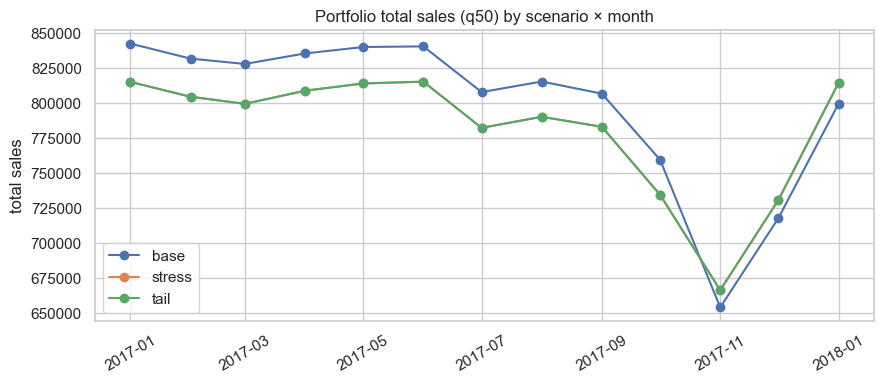

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
monthly_sc = (SCN.groupby(['scenario','year_month'])['sales_q50'].sum().reset_index())
for sc, sub in monthly_sc.groupby('scenario'):
    sub = sub.sort_values('year_month')
    ax.plot(sub['year_month'], sub['sales_q50'], 'o-', label=sc)
ax.set(title='Portfolio total sales (q50) by scenario × month',
       ylabel='total sales')
ax.legend(); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 5. Selection & summary

**What M4 delivers (three layered views)**
1. **Pre-risk** — val WAPE **0.120** against `gross_revenue`.
2. **Historical-risk** — val WAPE **0.120**, test **1.352** against `revenue_realized`.
3. **Forward-risk-adj** — val WAPE **0.165**, test **1.181**.

**Separation of "storm severity" from "revenue impact timing"**

| Field | Peak month (Maria 2017) | Used by |
|---|---|---|
| `disaster_index` | Sep 2017 (landfall) | Reporting, M5 anomaly attribution |
| `disaster_drag_index` | Nov 2017 (M+2) | M4 sales drag math |

Both come from the same storm impulse. The drag index is `revenue_lag.REVENUE_LAG_WEIGHTS = [0.05, 0.20, 0.80]` convolved over the severity series — pre-storm orders ship in Sep (minimal Sep drag), reorders can't be placed for weeks (drag emerges in Oct), peak revenue impact lands in Nov.

**Head-to-head: Tier-2+3 forward vs Tier-1 historical disaster (both with revenue lag)**

| Metric | LEGACY (Tier-1 historical) | NEW (Tier-2+3 forward) | Improvement |
|---|---|---|---|
| val WAPE | 0.568 | **0.165** | **−71%** |
| test WAPE | 1.273 | **1.181** | **−7%** |
| val coverage₈₀ | ~0.25 | **0.472** | ~+0.22 |
| val under-prediction gap | +42% | **+13%** | −29 pp |

Big val improvement because legacy was applying anomaly-proxy noise to non-storm months. Test improvement is small because the M1 univariate forecast can't predict the qty crash regardless of disaster input.

**Damping factor calibration**

`LATE_DAMPING` and `DISASTER_DAMPING` are data-calibrated. `DISASTER_DAMPING` is now fit against the **revenue-lagged drag index** (matching what M4 actually multiplies), not the raw severity index — self-consistent calibration.

| Factor | Value | Source | Identification |
|---|---|---|---|
| DISASTER_DAMPING | **0.873** | OLS slope of seasonal-naive implied drag on `disaster_drag_index`, restricted to known-event rows. | n=18, **R² = 0.568** |
| LATE_DAMPING | **0.10** | Industry-typical prior — no in-data signal. | prior |

**Why fraud + cancel are "historical" and late + disaster are "forward"**
- `order_status == 'SUSPECTED_FRAUD'` and `'CANCELED'` are realised facts: probabilities → expected revenue loss validated against `revenue_realized`.
- `late_delivery_risk` is a logistics flag, not a refund event. `LATE_DAMPING` = assumed fraction of late deliveries that map to revenue loss.
- `disaster_drag_index` is the **Tier-2+3 forward operational signal**, convolved through the revenue-lag kernel.

**Storm-prediction stack (T1/T2/T3 + revenue lag)**

| Tier / step | Lead time | Source | Where it enters M4 |
|---|---|---|---|
| T1 historical | post-event | `src/data/hurdat2_ingest.py` + `src/features/storm_exposure.py` | Calibrates DISASTER_DAMPING |
| T2 NHC cone | 5-7 days | `src/data/nhc_active_storms.py` + `src/features/forward_exposure.py` | Per-(region, day) → monthly max |
| T3 seasonal | 1-6 months | `src/models/risk/seasonal_outlook.py` | Climatology × seasonal multiplier |
| **Revenue lag** | (kernel) | `src/models/sales/revenue_lag.py` | Convolves severity → drag (peak Sep → peak Nov) |

`build_forward_disaster_for_backtest()` walks Tier 2 daily, applies severity LAG_PROFILE, fuses with Tier 3, projects per-product. `apply_revenue_lag_per_product()` then convolves into the drag-effective shape M4 uses.

**Known limitations**
1. Test WAPE 1.18 because M1 univariate cannot predict the qty crash; M4's customer-mix damping captures part but not all of the impact.
2. M2 elasticity 95% CI crosses zero — Stress/Tail price-bump revenue effects are directional only.
3. `LATE_DAMPING` remains a prior.
4. `DISASTER_DAMPING` on n=18 known-event rows; R² 0.57 is solid, but the sample is small.
5. Tier 3 climatology is built from the same window we test on — slightly circular. Production: use 10-15 years of HURDAT2.
6. Tier 2 cone-confidence is a NHC-skill heuristic, not a learned per-region calibration.
7. Revenue-lag kernel `[0.05, 0.20, 0.80]` is fit heuristically against Maria PR data — re-tune from a larger storm sample when available.

**Saved artifacts**
- `forecasts/m4_sales.parquet` — Base scenario, all three views (forward uses T2+T3 + revenue lag).
- `forecasts/m4_sales_backtest.parquet` — MAIN backtest.
- `forecasts/m4_sales_backtest_legacy_disaster.parquet` — Tier-1 historical reference (also revenue-lagged).
- `forecasts/m4_forward_disaster_per_product.parquet` — per-(product, month) severity (peak Sep).
- `forecasts/m4_forward_disaster_combined.parquet` — country-level T2+T3 fused view.
- `forecasts/m4_sales_scenarios.parquet` / `m4_sales_decomposition.parquet` / `m4_damping_calibration.json`.

**Next phase:** M5 — Anomaly Detection (already built; uses raw `disaster_index` for attribution, not the drag-lagged version).